In [1]:
# cell 1 - import libraries and check versions
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import math
import time
from tqdm import tqdm

import subprocess
subprocess.run(["pip", "install", "pytorch-fid", "--quiet"], check=True)

from pytorch_fid.inception import InceptionV3
from pytorch_fid.fid_score import calculate_frechet_distance
from scipy import linalg

print("pytorch-fid installed")
print(f"torch: {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")
print(f"numpy: {np.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"cuda {torch.cuda.is_available()} | device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}")

pytorch-fid installed
torch: 2.3.1+cu121
torchvision: 0.18.1+cu121
numpy: 2.4.6
matplotlib: 3.10.0
cuda True | device: Tesla P100-PCIE-16GB


In [2]:
# cell 2 - load cifar-10, inspect structure
raw = datasets.CIFAR10(root="./data", train=True, download=True, transform=transforms.ToTensor())

classes = raw.classes
targets = np.array(raw.targets)
imgs = raw.data # (50000, 32, 32, 3), uint8

print(f"train samples: {len(raw)}")
print(f"image shape: {imgs.shape[1:]} dtype={imgs.dtype}")
print(f"classes: {classes}")
print(f"\nper-class counts:")
for i, c in enumerate(classes):
    print(f"{c:12s}: {(targets == i).sum()}")

100%|██████████| 170498071/170498071 [00:03<00:00, 47721059.59it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
train samples: 50000
image shape: (32, 32, 3)  dtype=uint8
classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

per-class counts:
airplane    : 5000
automobile  : 5000
bird        : 5000
cat         : 5000
deer        : 5000
dog         : 5000
frog        : 5000
horse       : 5000
ship        : 5000
truck       : 5000


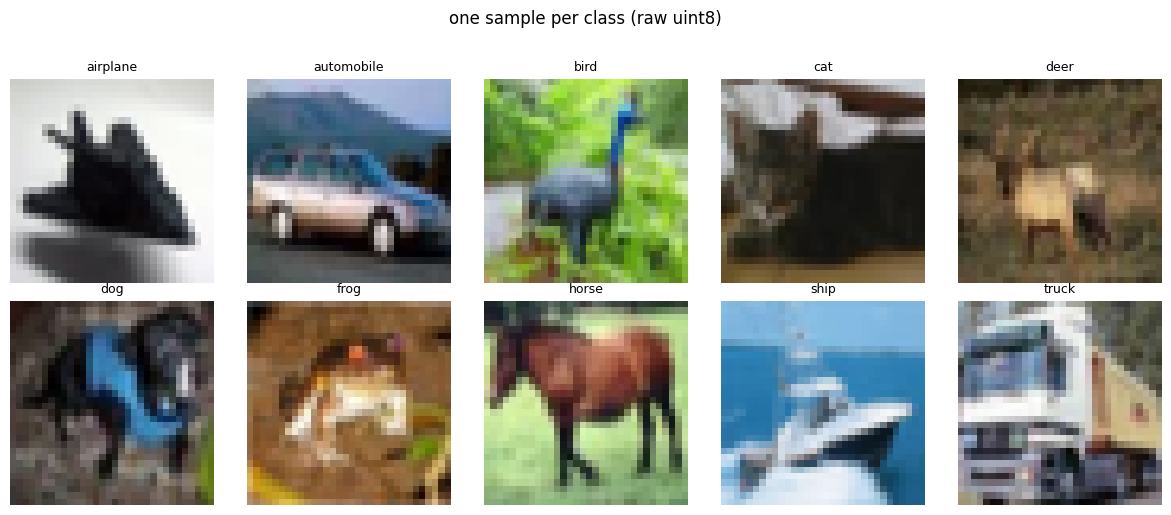

In [3]:
# cell 3 - 5x5 grid, one image per class (pick 5 random images per class → show first two rows as class representatives)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for cls_idx in range(10):
    idx = np.where(targets == cls_idx)[0][0]
    ax = axes[cls_idx // 5][cls_idx % 5]
    ax.imshow(imgs[idx])
    ax.set_title(classes[cls_idx], fontsize=9)
    ax.axis("off")
plt.suptitle("one sample per class (raw uint8)", y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# cell 4 - per-channel mean and std on raw [0, 255] data
imgs_f = imgs.astype(np.float32) # (50000, 32, 32, 3)
ch_mean = imgs_f.mean(axis=(0, 1, 2))
ch_std = imgs_f.std(axis=(0, 1, 2))

for i, ch in enumerate(["R", "G", "B"]):
    print(f"{ch} mean={ch_mean[i]:.3f}  std={ch_std[i]:.3f}")

R mean=125.307  std=62.993
G mean=122.950  std=62.089
B mean=113.866  std=66.705


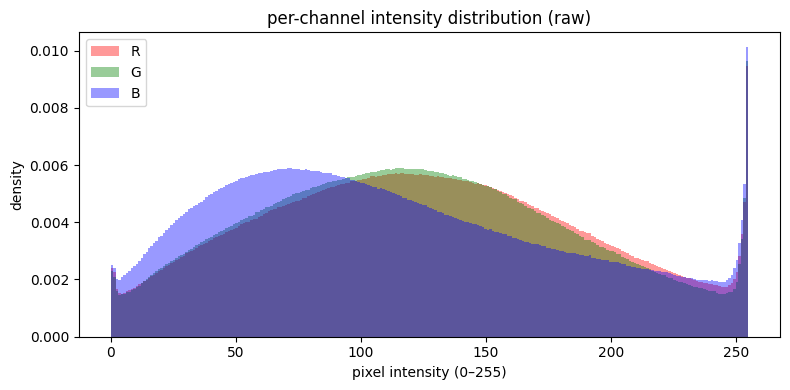

In [5]:
# cell 5 - per-channel pixel intensity histograms
fig, ax = plt.subplots(figsize=(8, 4))
colors  = ["red", "green", "blue"]
for i, (ch, col) in enumerate(zip(["R", "G", "B"], colors)):
    ax.hist(imgs_f[:, :, :, i].ravel(), bins=256, range=(0, 255),
            alpha=0.4, color=col, label=ch, density=True)
ax.set_xlabel("pixel intensity (0–255)")
ax.set_ylabel("density")
ax.set_title("per-channel intensity distribution (raw)")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# cell 6 — normalize to [-1, 1] and verify
imgs_norm = (imgs_f / 127.5) - 1.0 # (50000, 32, 32, 3)

vmin, vmax = imgs_norm.min(), imgs_norm.max()
vmean = imgs_norm.mean()
vstd = imgs_norm.std()

print(f"min: {vmin:.6f} (expected -1.0)")
print(f"max: {vmax:.6f} (expected  1.0)")
print(f"mean: {vmean:.6f} (expected ≈ 0.0)")
print(f"std: {vstd:.6f}")

assert vmin >= -1.0, f"min {vmin} out of range"
assert vmax <=  1.0, f"max {vmax} out of range"
print("\nassertions passed — range confirmed [-1, 1]")

min: -1.000000 (expected -1.0)
max: 1.000000 (expected  1.0)
mean: -0.053274 (expected ≈ 0.0)
std: 0.503138

assertions passed — range confirmed [-1, 1]


In [7]:
# cell 7 - define linear beta schedule and precompute noise schedule parameters
T = 1000
beta_min = 1e-4
beta_max = 0.02

betas = torch.linspace(beta_min, beta_max, T) # (T,)
alphas = 1.0 - betas # (T,)
alpha_bars = torch.cumprod(alphas, dim=0) # (T,)  ᾱ_t

print(f"betas: min={betas.min():.6f} max={betas.max():.6f}")
print(f"alphas: min={alphas.min():.6f} max={alphas.max():.6f}")
print(f"alpha_bars: t=1 → {alpha_bars[0]:.6f} t=T → {alpha_bars[-1]:.6f}")
print(f"\nexpected: alpha_bars[0] ≈ 1.0, alpha_bars[-1] ≈ 0.0")

betas: min=0.000100 max=0.020000
alphas: min=0.980000 max=0.999900
alpha_bars: t=1 → 0.999900 t=T → 0.000040

expected: alpha_bars[0] ≈ 1.0, alpha_bars[-1] ≈ 0.0


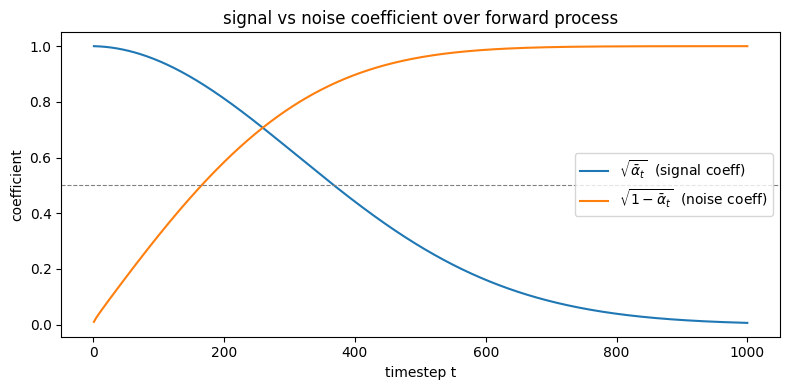

signal < noise after t = 260 (signal/noise crossover)


In [8]:
# cell 8 - verify signal-to-noise ratio collapse: plot sqrt(ᾱ_t) and sqrt(1−ᾱ_t) vs t
fig, ax = plt.subplots(figsize=(8, 4))
ts = np.arange(1, T + 1)
ax.plot(ts, alpha_bars.sqrt().numpy(), label=r"$\sqrt{\bar{\alpha}_t}$  (signal coeff)")
ax.plot(ts, (1 - alpha_bars).sqrt().numpy(), label=r"$\sqrt{1-\bar{\alpha}_t}$  (noise coeff)")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("timestep t")
ax.set_ylabel("coefficient")
ax.set_title("signal vs noise coefficient over forward process")
ax.legend()
plt.tight_layout()
plt.show()

crossover = (alpha_bars < 0.5).nonzero(as_tuple=True)[0][0].item() + 1
print(f"signal < noise after t = {crossover} (signal/noise crossover)")

In [9]:
# cell 9 - implement closed-form forward process q(x_t | x_0)
def q_sample(x0: torch.Tensor, t: torch.Tensor, alpha_bars: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Sample x_t ~ q(x_t | x_0) in closed form.
    x_t = sqrt(ᾱ_t) * x0 + sqrt(1 − ᾱ_t) * ε,  ε ~ N(0, I)

    Args:
        x0: clean image tensor (B, C, H, W)
        t: integer timestep indices (B,), 0-indexed
        alpha_bars: precomputed ᾱ values (T,)
    Returns:
        x_t: noisy image at timestep t
        eps: the noise that was added (target for the score network)
    """
    ab = alpha_bars[t].view(-1, 1, 1, 1) # (B, 1, 1, 1)
    eps = torch.randn_like(x0)
    x_t = ab.sqrt() * x0 + (1 - ab).sqrt() * eps
    return x_t, eps

# smoke test: single image, single timestep
x0_test = torch.zeros(1, 3, 32, 32) # black image
t_test = torch.tensor([499]) # t = 500
x_t, eps = q_sample(x0_test, t_test, alpha_bars)

ab_500 = alpha_bars[499].item()
print(f"t=500  ᾱ_t={ab_500:.4f}")
print(f"expected x_t mean ≈ 0.0 (signal=0 + noise centered at 0)")
print(f"x_t mean={x_t.mean():.4f} std={x_t.std():.4f}")
print(f"expected std ≈ sqrt(1-ᾱ_t) = {(1-ab_500)**0.5:.4f}")

t=500  ᾱ_t=0.0786
expected x_t mean ≈ 0.0 (signal=0 + noise centered at 0)
x_t mean=0.0012 std=0.9648
expected std ≈ sqrt(1-ᾱ_t) = 0.9599


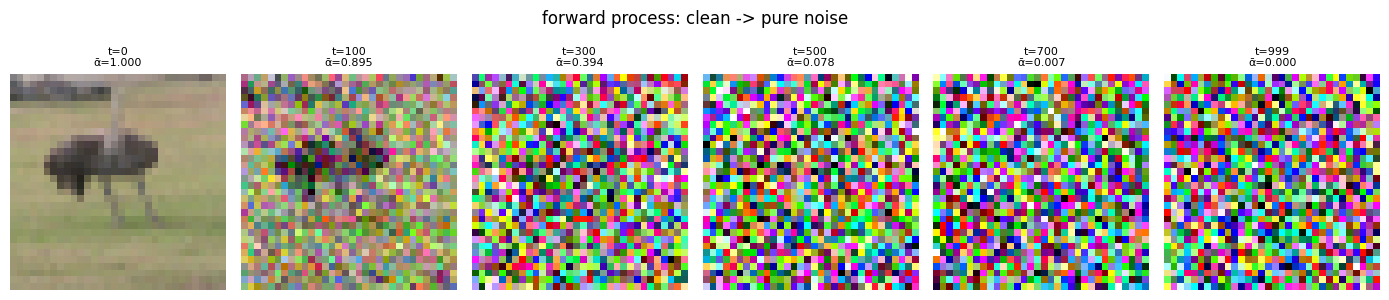

In [10]:
# cell 10 - visualize forward process for one image at t = 0, 100, 300, 500, 700, 999
# pick one image from the dataset and convert to tensor in [-1, 1]
sample_np = raw.data[42].astype(np.float32) / 127.5 - 1.0 # (32, 32, 3)
x0 = torch.tensor(sample_np).permute(2, 0, 1).unsqueeze(0) # (1, 3, 32, 32)

timesteps = [0, 100, 300, 500, 700, 999]
fig, axes = plt.subplots(1, 6, figsize=(14, 3))

for ax, t_val in zip(axes, timesteps):
    t_tensor = torch.tensor([t_val])
    x_t, _ = q_sample(x0, t_tensor, alpha_bars)
    img = x_t.squeeze(0).permute(1, 2, 0).numpy()
    img = (img + 1) / 2 # back to [0,1] for display
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ab_val = alpha_bars[t_val].item()
    ax.set_title(f"t={t_val}\nᾱ={ab_val:.3f}", fontsize=8)
    ax.axis("off")

plt.suptitle("forward process: clean -> pure noise", y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# cell 11 - numerical verification: at t=T, x_T should be ≈ N(0, I)
t_T = torch.tensor([T - 1])
x_T_samples = torch.stack([q_sample(x0, t_T, alpha_bars)[0] for _ in range(1000)]).squeeze(1)

print(f"at t=T: ᾱ_T = {alpha_bars[-1]:.6f}")
print(f"x_T empirical mean: {x_T_samples.mean():.4f} (expected ≈ 0.0)")
print(f"x_T empirical std: {x_T_samples.std():.4f} (expected ≈ 1.0)")
print(f"max |signal contrib| = {(alpha_bars[-1].sqrt() * x0.abs().max()).item():.6f} (should be negligible)")

at t=T: ᾱ_T = 0.000040
x_T empirical mean: 0.0002 (expected ≈ 0.0)
x_T empirical std: 0.9998 (expected ≈ 1.0)
max |signal contrib| = 0.004958 (should be negligible)


In [12]:
# cell 12 - implement the denoising score matching loss
def diffusion_loss(model: nn.Module, x0: torch.Tensor, alpha_bars: torch.Tensor) -> torch.Tensor:
    """
    Denoising score matching loss: L = E_{t, x0, ε} [ ||ε_θ(x_t, t) − ε||² ]
    Samples t uniformly, constructs x_t via q_sample, and regresses predicted noise onto true noise.

    Args:
        model: score network ε_θ(x_t, t) — implemented in stage 4
        x0: clean images (B, C, H, W) in [-1, 1]
        alpha_bars: precomputed ᾱ values (T,)
    Returns:
        scalar MSE loss
    """
    B = x0.shape[0]
    t = torch.randint(0, len(alpha_bars), (B,), device=x0.device)
    x_t, eps = q_sample(x0, t, alpha_bars.to(x0.device))
    eps_pred = model(x_t, t)
    return nn.functional.mse_loss(eps_pred, eps)

In [13]:
# cell 13 - verify score <-> noise equivalence numerically
# at a fixed t, compute the analytic score and confirm it equals -ε / sqrt(1 - ᾱ_t)

t_val = torch.tensor([499]) # t = 500
x_t, eps = q_sample(x0, t_val, alpha_bars)

ab = alpha_bars[499]
score_analytic = -(x_t - ab.sqrt() * x0) / (1 - ab) # direct formula
score_from_noise = -eps / (1 - ab).sqrt() # via reparameterization

max_diff = (score_analytic - score_from_noise).abs().max().item()
print(f"ᾱ_t = {ab:.6f}")
print(f"max |score_analytic − score_from_noise| = {max_diff:.2e}")
print(f"equivalence confirmed: {max_diff < 1e-5}")

ᾱ_t = 0.078587
max |score_analytic − score_from_noise| = 4.77e-07
equivalence confirmed: True


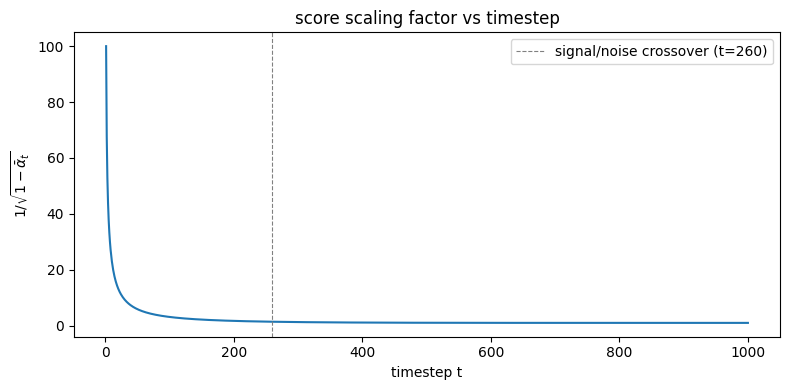

scale at t=1: 99.9917 (small — mostly signal, score is gentle)
scale at t=500: 1.0418 (moderate)
scale at t=999: 1.0000 (large — mostly noise, score is sharp)


In [14]:
# cell 14 - visualize scaling factor 1/sqrt(1 - ᾱ_t) across timesteps
scale = 1.0 / (1 - alpha_bars).sqrt()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, T + 1), scale.numpy())
ax.set_xlabel("timestep t")
ax.set_ylabel(r"$1/\sqrt{1 - \bar{\alpha}_t}$")
ax.set_title("score scaling factor vs timestep")
ax.axvline(260, color="gray", linestyle="--", linewidth=0.8, label="signal/noise crossover (t=260)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"scale at t=1: {scale[0]:.4f} (small — mostly signal, score is gentle)")
print(f"scale at t=500: {scale[499]:.4f} (moderate)")
print(f"scale at t=999: {scale[999]:.4f} (large — mostly noise, score is sharp)")

In [15]:
# cell 15 - sinusoidal timestep embedding
class SinusoidalTimestepEmbedding(nn.Module):
    """
    Encodes scalar timestep t into a continuous vector via sinusoidal frequencies.
    Identical in spirit to positional encodings in transformers — gives the network
    a smooth, unique representation of each noise level.
    """
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        # t: (B,) integer timesteps
        half = self.dim // 2
        freqs = torch.exp(math.log(10000) * torch.arange(half, device=t.device) / (half - 1)) # (half,)
        args = t[:, None].float() * freqs[None, :] # (B, half)
        return torch.cat([args.sin(), args.cos()], dim=-1) # (B, dim)

# verify shape and that different timesteps produce different embeddings
emb = SinusoidalTimestepEmbedding(dim=128)
t_a = torch.tensor([0, 499, 999])
out = emb(t_a)
print(f"embedding shape: {out.shape} (expected (3, 128))")
print(f"t=0 norm: {out[0].norm():.4f}")
print(f"t=499 norm: {out[1].norm():.4f}")
print(f"t=999 norm: {out[2].norm():.4f}")
print(f"t=0 vs t=499 cosine sim: {torch.nn.functional.cosine_similarity(out[0:1], out[1:2]).item():.4f}")

embedding shape: torch.Size([3, 128]) (expected (3, 128))
t=0 norm: 8.0000
t=499 norm: 8.0000
t=999 norm: 8.0000
t=0 vs t=499 cosine sim: 0.0918


In [16]:
# cell 16 - residual block with time conditioning
class ResBlock(nn.Module):
    """
    Conv -> GroupNorm -> SiLU -> Conv -> GroupNorm, with additive time embedding injection
    and a residual connection. Core building block of the U-Net encoder/decoder.
    """
    def __init__(self, in_ch: int, out_ch: int, time_dim: int):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.act = nn.SiLU()
        self.time_mlp = nn.Linear(time_dim, out_ch)
        # 1x1 conv to match channels if in_ch != out_ch
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = self.act(self.norm1(self.conv1(x)))
        h = h + self.time_mlp(self.act(t_emb))[:, :, None, None] # inject time
        h = self.act(self.norm2(self.conv2(h)))
        return h + self.skip(x)

# smoke test
rb = ResBlock(32, 64, time_dim=128)
x_ = torch.randn(2, 32, 16, 16)
t_ = torch.randn(2, 128)
out = rb(x_, t_)
print(f"resblock output shape: {out.shape} (expected (2, 64, 16, 16))")

resblock output shape: torch.Size([2, 64, 16, 16]) (expected (2, 64, 16, 16))


In [17]:
# cell 17 - U-Net score network
class UNet(nn.Module):
    """
    Time-conditioned U-Net. Takes noisy image x_t and timestep t,
    returns predicted noise ε_θ(x_t, t) of same spatial shape as input.
    Architecture: sinusoidal embedding -> encoder (downsample) -> bottleneck -> decoder (upsample + skip).
    """
    def __init__(self, in_ch: int=3, base_ch: int=64, time_dim: int=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimestepEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
        )
        # encoder
        self.enc1 = ResBlock(in_ch, base_ch, time_dim) # 32x32
        self.enc2 = ResBlock(base_ch, base_ch * 2, time_dim) # 16x16
        self.enc3 = ResBlock(base_ch * 2, base_ch * 4, time_dim) # 8x8
        self.down = nn.MaxPool2d(2)
        # bottleneck
        self.bot1 = ResBlock(base_ch * 4, base_ch * 4, time_dim)
        self.bot2 = ResBlock(base_ch * 4, base_ch * 4, time_dim)
        # decoder
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        self.dec3 = ResBlock(base_ch * 4 + base_ch * 4, base_ch * 2, time_dim)
        self.dec2 = ResBlock(base_ch * 2 + base_ch * 2, base_ch, time_dim)
        self.dec1 = ResBlock(base_ch + base_ch, base_ch, time_dim)
        # output projection
        self.out = nn.Conv2d(base_ch, in_ch, 1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(t) # (B, time_dim)
        # encode
        e1 = self.enc1(x, t_emb) # (B, 64,  32, 32)
        e2 = self.enc2(self.down(e1), t_emb) # (B, 128, 16, 16)
        e3 = self.enc3(self.down(e2), t_emb) # (B, 256,  8,  8)
        # bottleneck
        b  = self.bot2(self.bot1(self.down(e3), t_emb), t_emb) # (B, 256, 4, 4)
        # decode with skip connections
        d3 = self.dec3(torch.cat([self.up(b),  e3], dim=1), t_emb)
        d2 = self.dec2(torch.cat([self.up(d3), e2], dim=1), t_emb)
        d1 = self.dec1(torch.cat([self.up(d2), e1], dim=1), t_emb)
        return self.out(d1)

# instantiate and verify
model = UNet(in_ch=3, base_ch=64, time_dim=256)
x_ = torch.randn(2, 3, 32, 32)
t_ = torch.randint(0, 1000, (2,))
out = model(x_, t_)
print(f"output shape: {out.shape}  (expected (2, 3, 32, 32))")
total = sum(p.numel() for p in model.parameters())
print(f"total params: {total:,}  (must be ≤ 30M)")

output shape: torch.Size([2, 3, 32, 32])  (expected (2, 3, 32, 32))
total params: 5,053,763  (must be ≤ 30M)


In [18]:
# cell 18 - verify output shape matches input and gradients flow
loss = out.mean()
loss.backward()

grad_norms = {n: p.grad.norm().item() for n, p in model.named_parameters() if p.grad is not None}
print(f"layers with gradients: {len(grad_norms)}")
print(f"min grad norm: {min(grad_norms.values()):.2e}")
print(f"max grad norm: {max(grad_norms.values()):.2e}")
print(f"any zero grads: {any(v == 0.0 for v in grad_norms.values())}")

layers with gradients: 96
min grad norm: 1.84e-02
max grad norm: 6.07e+00
any zero grads: False


In [19]:
# cell 19 — training loop
SEED = 42
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
LR = 2e-4
N_EPOCHS = 100

transform  = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2 - 1), # [0,1] -> [-1,1]
])

train_set = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, drop_last=True)

model = UNet(in_ch=3, base_ch=64, time_dim=256).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LR)
ab_dev = alpha_bars.to(DEVICE)

print(f"device: {DEVICE}")
print(f"batches/ep: {len(train_loader)}")
print(f"params: {sum(p.numel() for p in model.parameters()):,}")

Files already downloaded and verified
device: cuda
batches/ep: 390
params: 5,053,763


In [20]:
# cell 20 — run training, log loss every epoch
loss_history = []

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    t0 = time.time()

    for imgs, _ in tqdm(train_loader, desc=f"epoch {epoch:3d}/{N_EPOCHS}", leave=False):
        imgs = imgs.to(DEVICE)
        optimizer.zero_grad()
        loss = diffusion_loss(model, imgs, ab_dev)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg = epoch_loss / len(train_loader)
    loss_history.append(avg)
    print(f"epoch {epoch:3d}/{N_EPOCHS}  loss={avg:.4f}  time={time.time()-t0:.1f}s")

torch.save(model.state_dict(), "ddpm_unet.pt")
print("\nmodel saved → ddpm_unet.pt")

epoch   1/100  loss=0.0836  time=22.9s


epoch   2/100  loss=0.0460  time=22.3s


epoch   3/100  loss=0.0421  time=22.3s


epoch   4/100  loss=0.0400  time=22.3s


epoch   5/100  loss=0.0395  time=22.3s


...

epoch  96/100  loss=0.0323  time=22.3s


epoch  97/100  loss=0.0322  time=22.3s


epoch  98/100  loss=0.0316  time=22.3s


epoch  99/100  loss=0.0318  time=22.3s


epoch 100/100  loss=0.0316  time=22.3s

model saved → ddpm_unet.pt


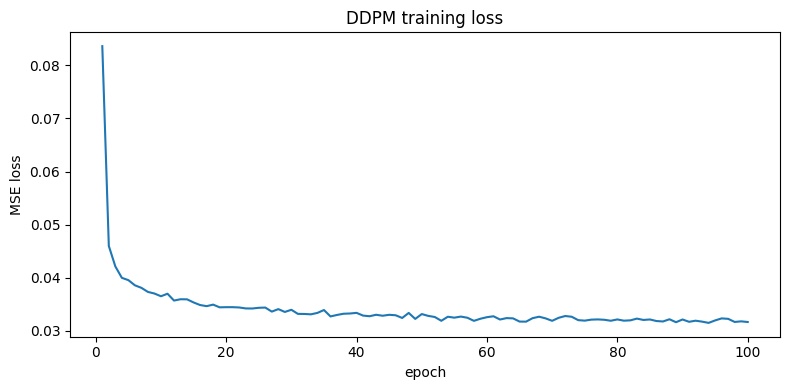

initial loss: 0.0836 (expected ≈ 1.0 — predicting random noise)
final loss: 0.0316 (expected < 0.1 after convergence)


In [21]:
# cell 21 - plot training loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, N_EPOCHS + 1), loss_history)
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss")
ax.set_title("DDPM training loss")
plt.tight_layout()
plt.show()

print(f"initial loss: {loss_history[0]:.4f} (expected ≈ 1.0 — predicting random noise)")
print(f"final loss: {loss_history[-1]:.4f} (expected < 0.1 after convergence)")

# Stage 5 — DDPM as a Wasserstein Gradient Flow (JKO Connection)

## The JKO Scheme

The **Jordan-Kinderlehrer-Otto (JKO) scheme** is a time-discretization of gradient flow in the space of probability distributions equipped with the Wasserstein-2 metric.

At each discrete step $k$, the next distribution $\rho_{k+1}$ is defined by:

$$\rho_{k+1} = \arg\min_{\rho} \left[ \underbrace{\mathrm{KL}(\rho \,\|\, p_{\text{data}})}_{\text{energy to minimize}} + \underbrace{\frac{1}{2\tau} W_2^2(\rho,\, \rho_k)}_{\text{proximal regularizer}} \right]$$

- $\mathcal{F}[\rho] = \mathrm{KL}(\rho \| p_{\text{data}})$: the functional being minimized — measures how far the current distribution is from the data distribution.
- $W_2^2(\rho, \rho_k)$: the squared Wasserstein-2 distance — penalizes moving too far in a single step. Acts as a speed limit in distribution space.
- $\tau$: the step size — corresponds to $\beta_t$ in the DDPM noise schedule.

## Connection to DDPM

Each DDPM **denoising step** is precisely a JKO update:

| JKO term | DDPM equivalent |
|---|---|
| $\rho_k$ | noisy distribution $q(x_t)$ at step $t$ |
| $\rho_{k+1}$ | denoised distribution $p_\theta(x_{t-1})$ |
| step size $\tau$ | noise schedule parameter $\beta_t$ |
| velocity field | score network $\varepsilon_\theta(x_t, t)$ |

The reverse SDE in DDPM implements the continuous limit of this scheme: as $\tau \to 0$ and $T \to \infty$, the discrete JKO steps converge to the **Fokker-Planck equation**, whose drift term is exactly the score function $\nabla_x \log p(x_t)$.

## Why This Reframes Training

Naively, training $\varepsilon_\theta$ looks like pixel-space curve-fitting — minimizing MSE between predicted and true noise vectors.

The JKO lens reveals what is actually happening:

> **Training is gradient descent in the space of probability distributions.**
> The score network learns the velocity field of a Wasserstein gradient flow
> that transports $\mathcal{N}(0, I)$ toward $p_{\text{data}}$ along the
> direction of steepest descent of $\mathrm{KL}(\cdot \| p_{\text{data}})$.

This is not curve-fitting. It is learning the geometry of the Wasserstein manifold — specifically, the vector field that moves probability mass most efficiently from noise to data.

## Implication for Sampling Quality

Because each denoising step is a proximal minimization, the step size $\beta_t$ directly controls the trade-off between:
- **fidelity to data** (minimize $\mathrm{KL}$), and
- **stability** (stay close to $\rho_k$ via $W_2$ penalty).

Too large a $\beta_t$: distribution jumps erratically — proximal term too weak. Too small a $\beta_t$: convergence is slow — requires many NFEs.

This is the mathematical reason why DDPM needs large $T$ steps, and why Rectified Flow can do better — it finds straighter paths in distribution space, reducing the number of proximal steps needed.

In [22]:
# cell 22 - implement ddpm reverse sampler
@torch.no_grad()
def ddpm_sample(model: nn.Module, alpha_bars: torch.Tensor,
                betas: torch.Tensor, n_samples: int=16,
                device: torch.device=DEVICE) -> torch.Tensor:
    """
    Full T-step DDPM reverse sampler.
    Starts from x_T ~ N(0,I) and applies learned reverse transition
    p_θ(x_{t-1}|x_t) for T steps. Returns denoised images in [-1,1].
    """
    alphas = 1.0 - betas
    ab = alpha_bars.to(device)
    al = alphas.to(device)
    be = betas.to(device)

    x = torch.randn(n_samples, 3, 32, 32, device=device) # x_T ~ N(0,I)

    for t in reversed(range(len(be))):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
        eps_pred = model(x, t_batch)

        # compute reverse mean μ_θ
        coeff = be[t] / (1 - ab[t]).sqrt()
        mean = (1 / al[t].sqrt()) * (x - coeff * eps_pred)

        if t > 0:
            sigma = be[t].sqrt()
            x = mean + sigma * torch.randn_like(x)
        else:
            x = mean # no noise at t=0

    return x

# smoke test: single forward pass through sampler, check output shape and range
model.eval()
samples = ddpm_sample(model, alpha_bars, betas, n_samples=4)
print(f"output shape: {samples.shape} (expected (4, 3, 32, 32))")
print(f"min={samples.min():.3f} max={samples.max():.3f} (expected roughly in [-1,1])")

output shape: torch.Size([4, 3, 32, 32]) (expected (4, 3, 32, 32))
min=-1.047 max=0.995 (expected roughly in [-1,1])


In [23]:
# cell 23 - strided sampler (ddim-style, configurable nfe)
@torch.no_grad()
def ddpm_sample_strided(model: nn.Module, alpha_bars: torch.Tensor,
                        betas: torch.Tensor, n_samples: int=16,
                        n_steps: int=100,
                        device: torch.device=DEVICE) -> tuple[torch.Tensor, int]:
    """
    Strided DDPM sampler using a subset of T timesteps.
    Selects n_steps evenly spaced timesteps from [0, T-1].
    Returns (samples, nfe) where nfe = n_steps.
    """
    T = len(betas)
    timesteps = list(reversed(range(0, T, T // n_steps)))[:n_steps]
    ab = alpha_bars.to(device)
    be = betas.to(device)

    x = torch.randn(n_samples, 3, 32, 32, device=device)

    for i, t in enumerate(timesteps):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
        eps_pred = model(x, t_batch)

        ab_t = ab[t]
        ab_prev = ab[timesteps[i + 1]] if i + 1 < len(timesteps) else torch.tensor(1.0)

        # reconstruct x0 estimate
        x0_hat = (x - (1 - ab_t).sqrt() * eps_pred) / ab_t.sqrt()
        x0_hat = x0_hat.clamp(-1, 1)

        # compute x_{t-1} mean
        mean = ab_prev.sqrt() * x0_hat + (1 - ab_prev).sqrt() * eps_pred

        if i < len(timesteps) - 1:
            sigma = ((1 - ab_prev) / (1 - ab_t) * (1 - ab_t / ab_prev)).sqrt()
            x = mean + sigma * torch.randn_like(x)
        else:
            x = mean

    return x, n_steps

samples_strided, nfe = ddpm_sample_strided(model, alpha_bars, betas, n_samples=4, n_steps=100)
print(f"strided output shape: {samples_strided.shape}")
print(f"nfe used: {nfe}")
print(f"min={samples_strided.min():.3f} max={samples_strided.max():.3f}")

strided output shape: torch.Size([4, 3, 32, 32])
nfe used: 100
min=-1.000 max=1.000


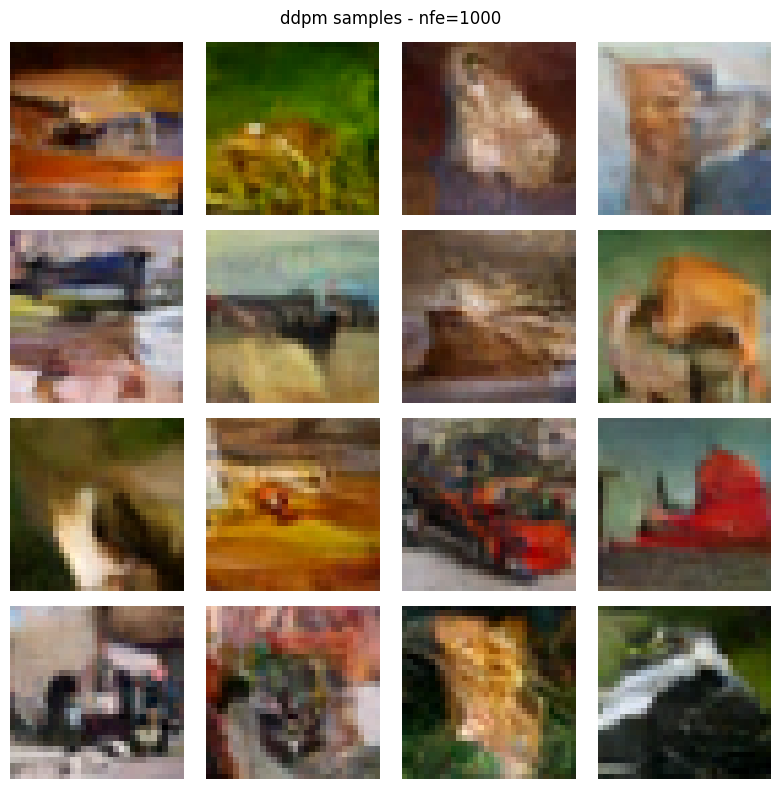

total nfe (full sampler): 1000
total nfe (strided, 100): 100


In [24]:
# cell 24 - generate 4x4 grid of samples and visualize
model.eval()
samples = ddpm_sample(model, alpha_bars, betas, n_samples=16)

def show_grid(imgs: torch.Tensor, title: str, nrow: int=4):
    imgs = (imgs.clamp(-1, 1) + 1) / 2 # [-1,1] → [0,1]
    imgs = imgs.cpu().permute(0, 2, 3, 1).numpy()
    fig, axes = plt.subplots(nrow, nrow, figsize=(8, 8))
    for i, ax in enumerate(axes.ravel()):
        ax.imshow(imgs[i])
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_grid(samples, f"ddpm samples - nfe={T}")
print(f"total nfe (full sampler): {T}")
print(f"total nfe (strided, 100): 100")

In [25]:
# cell 25 - verify nfe counts explicitly
nfe_full = T
_, nfe_100 = ddpm_sample_strided(model, alpha_bars, betas, n_samples=1, n_steps=100)
_, nfe_10 = ddpm_sample_strided(model, alpha_bars, betas, n_samples=1, n_steps=10)

print(f"full sampler nfe: {nfe_full}")
print(f"strided (100) nfe: {nfe_100}")
print(f"strided (10) nfe: {nfe_10}")
print(f"\neach nfe = one forward pass through ε_θ")

full sampler nfe: 1000
strided (100) nfe: 100
strided (10) nfe: 10

each nfe = one forward pass through ε_θ


In [26]:
# cell 26 - rectified flow training objective
def rectified_flow_loss(model: nn.Module, x0: torch.Tensor) -> torch.Tensor:
    """
    Rectified flow loss: L = E_{x0~data, x1~N(0,I), t~U[0,1]} ||v_θ(x_t,t) − (x1−x0)||²
    x_t = (1−t)x0 + t*x1  is the straight-line interpolation.
    target velocity is the constant vector (x1 − x0).
    """
    B = x0.shape[0]
    x1 = torch.randn_like(x0) # noise
    t = torch.rand(B, device=x0.device) # t ~ U[0,1]
    t4 = t.view(-1, 1, 1, 1)
    x_t = (1 - t4) * x0 + t4 * x1 # interpolation
    target = x1 - x0 # constant velocity
    # reuse t as integer-scaled timestep for embedding (map [0,1] → [0,T-1])
    t_int = (t * (T - 1)).long()
    v_pred = model(x_t, t_int)
    return nn.functional.mse_loss(v_pred, target)

# smoke test
rf_model = UNet(in_ch=3, base_ch=64, time_dim=256).to(DEVICE)
x_test = torch.randn(4, 3, 32, 32, device=DEVICE)
loss_test = rectified_flow_loss(rf_model, x_test)
print(f"rectified flow loss (random init): {loss_test.item():.4f}")
print(f"expected: ~2.0 (var of x1−x0 = var(x1)+var(x0) ≈ 1+1 = 2)")

rectified flow loss (random init): 2.2064
expected: ~2.0 (var of x1−x0 = var(x1)+var(x0) ≈ 1+1 = 2)


In [27]:
# cell 27 - verify interpolation at boundary timesteps
x0_t = torch.randn(2, 3, 32, 32)
x1_t = torch.randn(2, 3, 32, 32)

t0 = torch.zeros(2, 1, 1, 1)
t1 = torch.ones(2,  1, 1, 1)

xt_0 = (1 - t0) * x0_t + t0 * x1_t
xt_1 = (1 - t1) * x0_t + t1 * x1_t

print(f"at t=0: max|x_t - x0| = {(xt_0 - x0_t).abs().max():.2e} (expected 0.0)")
print(f"at t=1: max|x_t - x1| = {(xt_1 - x1_t).abs().max():.2e} (expected 0.0)")

at t=0: max|x_t - x0| = 0.00e+00 (expected 0.0)
at t=1: max|x_t - x1| = 0.00e+00 (expected 0.0)


In [28]:
# cell 28 - train rectified flow model
torch.manual_seed(SEED)

rf_model = UNet(in_ch=3, base_ch=64, time_dim=256).to(DEVICE)
rf_optim = optim.AdamW(rf_model.parameters(), lr=LR)
rf_history = []

for epoch in range(1, N_EPOCHS + 1):
    rf_model.train()
    epoch_loss = 0.0
    t0 = time.time()

    for imgs, _ in tqdm(train_loader, desc=f"epoch {epoch:3d}/{N_EPOCHS}", leave=False):
        imgs = imgs.to(DEVICE)
        rf_optim.zero_grad()
        loss = rectified_flow_loss(rf_model, imgs)
        loss.backward()
        nn.utils.clip_grad_norm_(rf_model.parameters(), 1.0)
        rf_optim.step()
        epoch_loss += loss.item()

    avg = epoch_loss / len(train_loader)
    rf_history.append(avg)
    print(f"epoch {epoch:3d}/{N_EPOCHS}  loss={avg:.4f}  time={time.time()-t0:.1f}s")

torch.save(rf_model.state_dict(), "rectified_flow.pt")
print("\nmodel saved → rectified_flow.pt")

epoch   1/100  loss=0.3067  time=22.3s


epoch   2/100  loss=0.2319  time=22.3s


epoch   3/100  loss=0.2204  time=22.3s


epoch   4/100  loss=0.2150  time=22.3s


epoch   5/100  loss=0.2112  time=22.3s


...

epoch  96/100  loss=0.1836  time=22.3s


epoch  97/100  loss=0.1827  time=22.3s


epoch  98/100  loss=0.1837  time=22.3s


epoch  99/100  loss=0.1840  time=22.2s


epoch 100/100  loss=0.1838  time=22.2s

model saved → rectified_flow.pt


In [29]:
# cell 29 - rectified flow ode sampler
@torch.no_grad()
def rf_sample(model: nn.Module, n_samples: int=16,
              n_steps: int=100, device: torch.device=DEVICE) -> tuple[torch.Tensor, int]:
    """
    Euler integration of the learned ODE dx/dt = v_θ(x,t).
    Integrates from t=1 (noise) to t=0 (data) with n_steps uniform steps.
    """
    dt = 1.0 / n_steps
    x = torch.randn(n_samples, 3, 32, 32, device=device) # x_1 ~ N(0,I)

    for i in range(n_steps):
        t_val = 1.0 - i * dt # integrate 1→0
        t_int = torch.full((n_samples,), int(t_val * (T-1)), device=device, dtype=torch.long)
        v = model(x, t_int)
        x = x - v * dt # euler step

    return x, n_steps

# smoke test
rf_model.eval()
rf_samples, nfe = rf_sample(rf_model, n_samples=4, n_steps=100)
print(f"output shape: {rf_samples.shape}")
print(f"nfe: {nfe}")
print(f"min={rf_samples.min():.3f} max={rf_samples.max():.3f}")

output shape: torch.Size([4, 3, 32, 32])
nfe: 100
min=-1.241 max=1.078


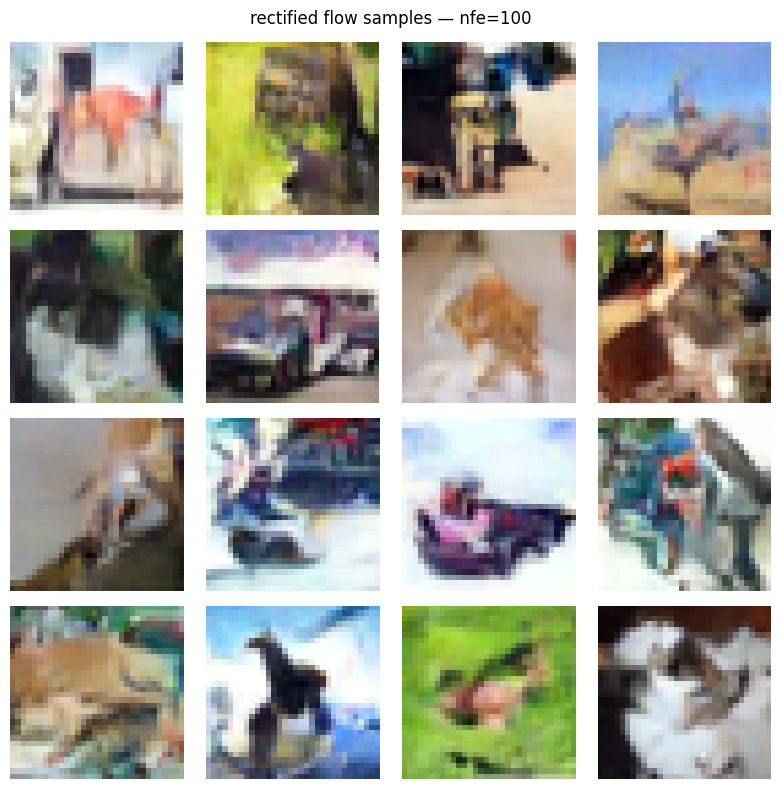

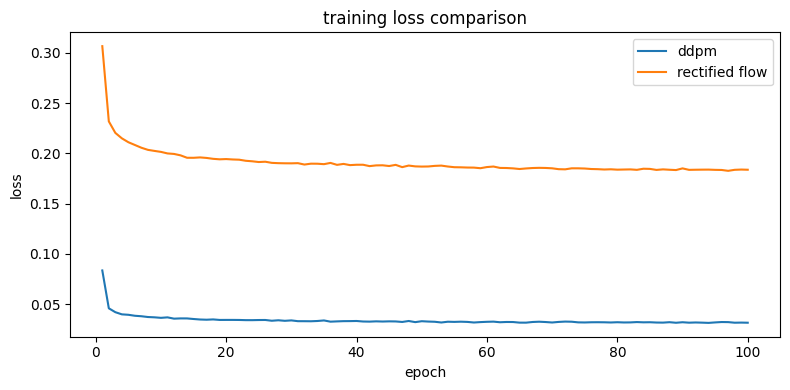

ddpm final loss: 0.0316
rf final loss: 0.1838
note: losses are not directly comparable — different target scales


In [30]:
# cell 30 - visualize rectified flow samples and compare loss curves
rf_samples_grid, _ = rf_sample(rf_model, n_samples=16, n_steps=100)
show_grid(rf_samples_grid, "rectified flow samples — nfe=100")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, N_EPOCHS + 1), loss_history, label="ddpm")
ax.plot(range(1, N_EPOCHS + 1), rf_history, label="rectified flow")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("training loss comparison")
ax.legend()
plt.tight_layout()
plt.show()

print(f"ddpm final loss: {loss_history[-1]:.4f}")
print(f"rf final loss: {rf_history[-1]:.4f}")
print(f"note: losses are not directly comparable — different target scales")

# Stage 8 — The Push-Forward View: Unifying DDPM and Rectified Flow

## The Push-Forward Operator

For a measurable map $T: \mathbb{R}^d \to \mathbb{R}^d$ and source distribution $\mu$, the **push-forward** $T_\sharp \mu = \nu$ means:

$$\nu(A) = \mu(T^{-1}(A)) \quad \forall \text{ measurable } A$$

In plain terms: if you draw samples $x \sim \mu$ and apply $T$, the outputs $T(x)$ are distributed as $\nu$. Both DDPM and Rectified Flow learn different parameterizations of this map.

---

## Rectified Flow: Deterministic Push-Forward

The ODE flow map $\varphi_t: \mathbb{R}^d \to \mathbb{R}^d$ integrates the learned velocity field from $t=1$ to $t=0$:

$$\varphi_0(x) = x + \int_1^0 v_\theta(x_t, t)\, dt$$

The push-forward equation is:

$$(\varphi_0)_\sharp \mathcal{N}(0, \mathbf{I}) = p_{\text{data}}$$

The transport map is $T = \varphi_0$ — a **single deterministic function**.
$v_\theta$ parameterizes $T$ as its infinitesimal generator: the network predicts local velocity arrows whose path integral accumulates into the full transport.

Because Rectified Flow trains $v_\theta$ toward straight-line targets $(x_1 - x_0)$, the integral is nearly linear - Euler integration with few steps closely approximates the exact $\varphi_0$.

---

## DDPM: Stochastic Push-Forward via Markov Kernel

DDPM defines a **stochastic** transport through a composition of Markov kernels:

$$T_\sharp \mu = (K_1 \circ K_2 \circ \cdots \circ K_T)_\sharp \mathcal{N}(0, \mathbf{I})$$

where each kernel $K_t$ samples from $p_\theta(x_{t-1} \mid x_t)$.

The push-forward is not a single deterministic map but a sequence of conditional Gaussians, each shifting probability mass by one denoising step.

| | Rectified Flow | DDPM |
|---|---|---|
| Push-forward type | deterministic | stochastic |
| Transport map $T$ | $\varphi_0$ (ODE flow) | $K_1 \circ \cdots \circ K_T$ (Markov chain) |
| Generator | $v_\theta$ (velocity field) | $\varepsilon_\theta$ (score / noise predictor) |
| Path geometry | straight (≈ OT geodesic) | curved (variance-preserving SDE) |
| NFE to approximate $T$ | low (path is straight) | high (path is curved) |

---

## Unification

Both models solve the same problem:

$$\text{find } T \text{ such that } T_\sharp \mu = \nu, \quad \mu = \mathcal{N}(0,\mathbf{I}),\quad \nu = p_{\text{data}}$$

They differ only in how $T$ is parameterized and how straight its trajectories are. Rectified Flow's straight paths make $T$ easier to approximate numerically — this is the geometric reason it achieves lower FID at fewer NFEs.

In [31]:
# cell 31 - compute inception statistics helper
def compute_inception_stats(images: torch.Tensor, batch_size: int=128,
                             device: torch.device=DEVICE) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute mean and covariance of Inception-v3 pool3 features.
    images: (N, 3, H, W) in [-1,1]. Returns (mu, sigma) for FID computation.
    """
    block_idx = InceptionV3.BLOCK_INDEX_BY_DIM[2048]
    inception = InceptionV3([block_idx]).to(device).eval()

    # inception expects [0,1] and at least 75x75 - upsample cifar-10 32→75
    imgs_01 = (images.clamp(-1, 1) + 1) / 2
    imgs_up = F.interpolate(imgs_01, size=(75, 75), mode="bilinear", align_corners=False)

    feats = []
    loader = DataLoader(TensorDataset(imgs_up), batch_size=batch_size)
    with torch.no_grad():
        for (x,) in loader:
            f = inception(x.to(device))[0].squeeze(-1).squeeze(-1) # (B, 2048)
            feats.append(f.cpu())

    feats = torch.cat(feats, dim=0).numpy()
    mu = feats.mean(axis=0)
    sigma = np.cov(feats, rowvar=False)
    return mu, sigma

print("inception stats function defined!")

inception stats function defined!


In [32]:
# cell 32 - precompute real data inception statistics (done once)
print("computing real data inception stats on 10,000 cifar-10 samples...")
real_loader  = DataLoader(train_set, batch_size=256, shuffle=True)
real_imgs = []
for imgs, _ in real_loader:
    real_imgs.append(imgs)
    if len(torch.cat(real_imgs)) >= 10000:
        break
real_imgs = torch.cat(real_imgs)[:10000] # (10000, 3, 32, 32) in [-1,1]

mu_real, sigma_real = compute_inception_stats(real_imgs)
print(f"real stats computed — mu shape: {mu_real.shape} sigma shape: {sigma_real.shape}")

computing real data inception stats on 10,000 cifar-10 samples...


Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 208MB/s]


real stats computed — mu shape: (2048,) sigma shape: (2048, 2048)


In [33]:
# cell 33 - fid computation function
def compute_fid(mu1, sigma1, mu2, sigma2) -> float:
    """
    Frechet Inception Distance between two Gaussian distributions.
    FID = ||mu1-mu2||² + Tr(sigma1 + sigma2 − 2*sqrt(sigma1@sigma2))
    """
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return float(fid)

# sanity check: fid of real vs real should be ≈ 0
mu_real2, sigma_real2 = compute_inception_stats(real_imgs[:5000])
mu_real3, sigma_real3 = compute_inception_stats(real_imgs[5000:])
fid_sanity = compute_fid(mu_real2, sigma_real2, mu_real3, sigma_real3)
print(f"fid (real vs real split): {fid_sanity:.4f} (expected < 12.0)")

/tmp/ipykernel_182/2021247524.py:8: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)


fid (real vs real split): 10.2679 (expected < 12.0)


In [34]:
# cell 34 - run benchmark across nfe budgets
NFE_BUDGETS  = [10, 20, 50, 100, 200]
N_EVAL = 10000
EVAL_BATCH = 500

def generate_samples(sampler_fn, n_total: int, batch: int) -> torch.Tensor:
    """generate n_total samples in batches using sampler_fn."""
    out = []
    for _ in tqdm(range(n_total // batch), desc="generating"):
        s, _ = sampler_fn(batch)
        out.append(s.cpu())
    return torch.cat(out, dim=0)

ddpm_fids = {}
rf_fids = {}

model.eval()
rf_model.eval()

for nfe in tqdm(NFE_BUDGETS, desc="nfe budgets"):
    print(f"\nnfe={nfe}")

    ddpm_fn = lambda n, k=nfe: ddpm_sample_strided(model, alpha_bars, betas, n_samples=n, n_steps=k, device=DEVICE)
    rf_fn = lambda n, k=nfe: rf_sample(rf_model, n_samples=n, n_steps=k, device=DEVICE)

    ddpm_imgs = generate_samples(ddpm_fn, N_EVAL, EVAL_BATCH)
    rf_imgs = generate_samples(rf_fn, N_EVAL, EVAL_BATCH)

    mu_ddpm, s_ddpm = compute_inception_stats(ddpm_imgs)
    mu_rf, s_rf = compute_inception_stats(rf_imgs)

    ddpm_fids[nfe] = compute_fid(mu_real, sigma_real, mu_ddpm, s_ddpm)
    rf_fids[nfe] = compute_fid(mu_real, sigma_real, mu_rf, s_rf)

    print(f" ddpm fid: {ddpm_fids[nfe]:.2f}")
    print(f" rf fid: {rf_fids[nfe]:.2f}")

nfe budgets:   0%|          | 0/5 [00:00<?, ?it/s]


nfe=10



generating: 100%|██████████| 20/20 [00:16<00:00,  1.25it/s]

generating: 100%|██████████| 20/20 [00:15<00:00,  1.26it/s]
/tmp/ipykernel_182/2021247524.py:8: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
nfe budgets:  20%|██        | 1/5 [01:34<06:16, 94.08s/it]

 ddpm fid: 405.60
 rf fid: 47.39

nfe=20



generating: 100%|██████████| 20/20 [00:31<00:00,  1.59s/it]

nfe budgets:  40%|████      | 2/5 [03:39<05:37, 112.47s/it]

...

 ddpm fid: 436.92
 rf fid: 43.96

nfe=100



generating: 100%|██████████| 20/20 [02:39<00:00,  7.95s/it]

nfe budgets:  80%|████████  | 4/5 [13:38<04:07, 247.32s/it]

 ddpm fid: 435.09
 rf fid: 43.01

nfe=200



generating: 100%|██████████| 20/20 [05:17<00:00, 15.87s/it]

nfe budgets: 100%|██████████| 5/5 [25:13<00:00, 302.61s/it]

 ddpm fid: 434.03
 rf fid: 43.02


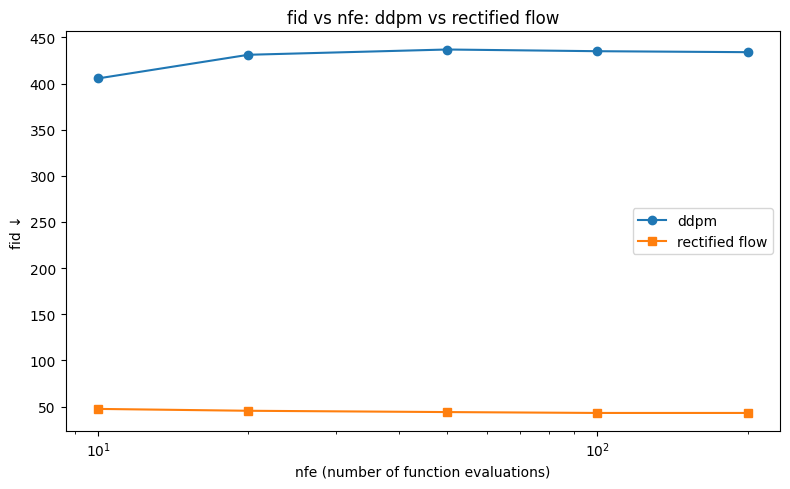

In [35]:
# cell 35 - plot fid vs nfe curves
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(NFE_BUDGETS, [ddpm_fids[n] for n in NFE_BUDGETS], "o-", label="ddpm")
ax.plot(NFE_BUDGETS, [rf_fids[n] for n in NFE_BUDGETS], "s-", label="rectified flow")
ax.set_xlabel("nfe (number of function evaluations)")
ax.set_ylabel("fid ↓")
ax.set_title("fid vs nfe: ddpm vs rectified flow")
ax.set_xscale("log")
ax.legend()
plt.tight_layout()
plt.show()

In [36]:
# cell 36 - results table
print(f"{'nfe':>6} | {'ddpm fid':>10} | {'rf fid':>10} | {'rf advantage':>12}")
print("-" * 46)
for nfe in NFE_BUDGETS:
    adv = ddpm_fids[nfe] - rf_fids[nfe]
    print(f"{nfe:>6} | {ddpm_fids[nfe]:>10.2f} | {rf_fids[nfe]:>10.2f} | {adv:>+12.2f}")
print("\n(+) rf advantage = ddpm fid − rf fid; positive means rf is better")

   nfe |   ddpm fid |     rf fid | rf advantage
----------------------------------------------
    10 |     405.60 |      47.39 |      +358.21
    20 |     431.21 |      45.37 |      +385.84
    50 |     436.92 |      43.96 |      +392.96
   100 |     435.09 |      43.01 |      +392.07
   200 |     434.03 |      43.02 |      +391.02

(+) rf advantage = ddpm fid − rf fid; positive means rf is better
